In [7]:
# ============================================
# L&T Task 4: Transfer Learning using VGG16
# Dataset: CIFAR-10
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Load CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1140s 7us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


In [10]:
# Create validation set from training data

validation_split = 0.1

num_validation = int(len(x_train) * validation_split)

x_val = x_train[-num_validation:]
y_val = y_train[-num_validation:]

x_train = x_train[:-num_validation]
y_train = y_train[:-num_validation]

print("Training:", x_train.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test.shape)

Training: (40500, 32, 32, 3)
Validation: (4500, 32, 32, 3)
Testing: (10000, 32, 32, 3)


In [11]:
# VGG16 input size

IMG_SIZE = 96

def prepare_images(images):
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images

In [12]:
# Create TensorFlow datasets

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

def preprocess_dataset(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_dataset = (
    train_dataset
    .map(preprocess_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .map(preprocess_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(preprocess_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets prepared successfully.")

Datasets prepared successfully.


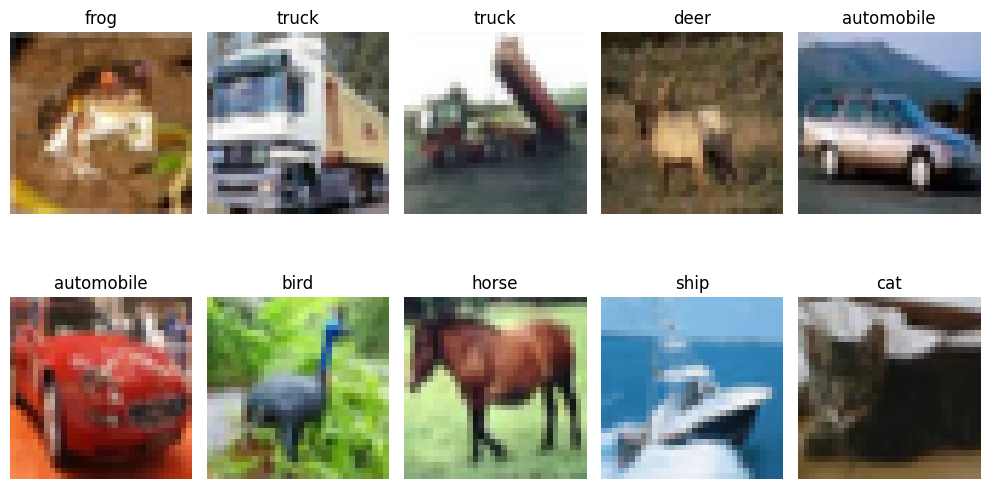

In [9]:
# Display sample CIFAR-10 images

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Load VGG16 pretrained on ImageNet
# include_top=False removes the original 1000-class classifier

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained VGG16 layers
base_model.trainable = False

print("VGG16 loaded successfully.")
print("Total layers:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully.
Total layers: 19


In [14]:
# Build VGG16 Transfer Learning model

model = keras.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Compile the transfer-learning model

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [16]:
# Train the classifier on top of frozen VGG16

initial_epochs = 5

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=initial_epochs
)

Epoch 1/5
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.4908 - loss: 2.7992 - val_accuracy: 0.7242 - val_loss: 0.8720
Epoch 2/5
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.6592 - loss: 1.1145 - val_accuracy: 0.7627 - val_loss: 0.7245
Epoch 3/5
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7132 - loss: 0.8863 - val_accuracy: 0.7807 - val_loss: 0.6479
Epoch 4/5
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step - accuracy: 0.7478 - loss: 0.7710 - val_accuracy: 0.7916 - val_loss: 0.6113
Epoch 5/5
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 49s 36ms/step - accuracy: 0.7712 - loss: 0.6889 - val_accuracy: 0.8022 - val_loss: 0.5820


In [17]:
# Evaluate VGG16 Transfer Learning model

transfer_test_loss, transfer_test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n===== VGG16 TRANSFER LEARNING RESULTS =====")
print(f"Test Loss     : {transfer_test_loss:.4f}")
print(f"Test Accuracy : {transfer_test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8023 - loss: 0.5888

===== VGG16 TRANSFER LEARNING RESULTS =====
Test Loss     : 0.5888
Test Accuracy : 0.8023


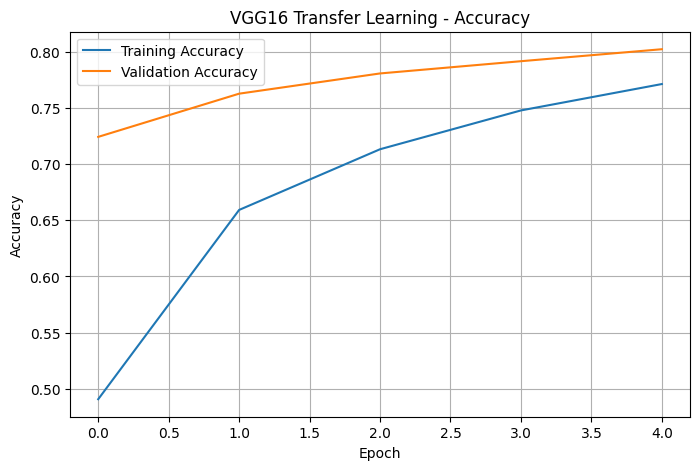

In [18]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

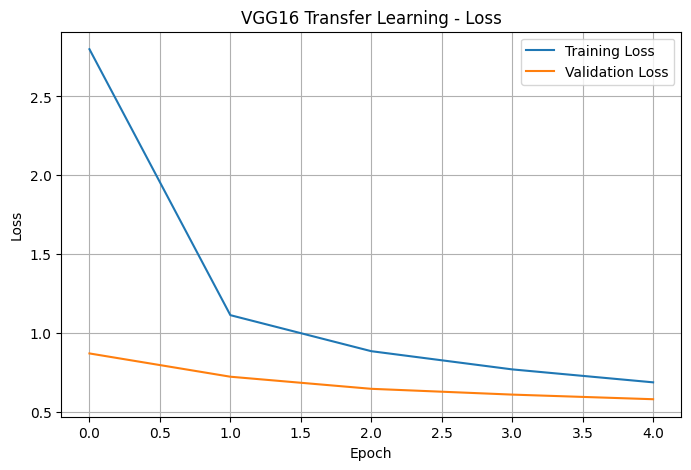

In [19]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Transfer Learning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

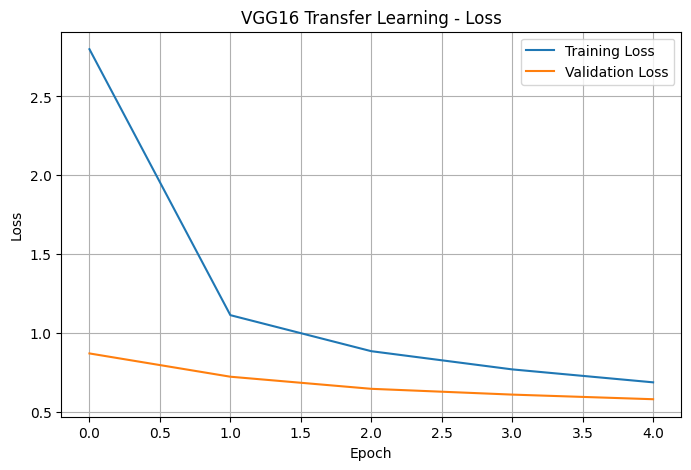

In [20]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Transfer Learning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Generate predictions on CIFAR-10 test set

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully.
Number of test predictions: 10000


In [22]:
from sklearn.metrics import classification_report

print("===== VGG16 CLASSIFICATION REPORT =====\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== VGG16 CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

    airplane     0.8014    0.8310    0.8159      1000
  automobile     0.8879    0.8950    0.8914      1000
        bird     0.7767    0.7270    0.7510      1000
         cat     0.6894    0.6480    0.6680      1000
        deer     0.7421    0.7540    0.7480      1000
         dog     0.7500    0.7350    0.7424      1000
        frog     0.8149    0.8540    0.8340      1000
       horse     0.8125    0.8320    0.8221      1000
        ship     0.8637    0.8680    0.8658      1000
       truck     0.8738    0.8790    0.8764      1000

    accuracy                         0.8023     10000
   macro avg     0.8012    0.8023    0.8015     10000
weighted avg     0.8012    0.8023    0.8015     10000



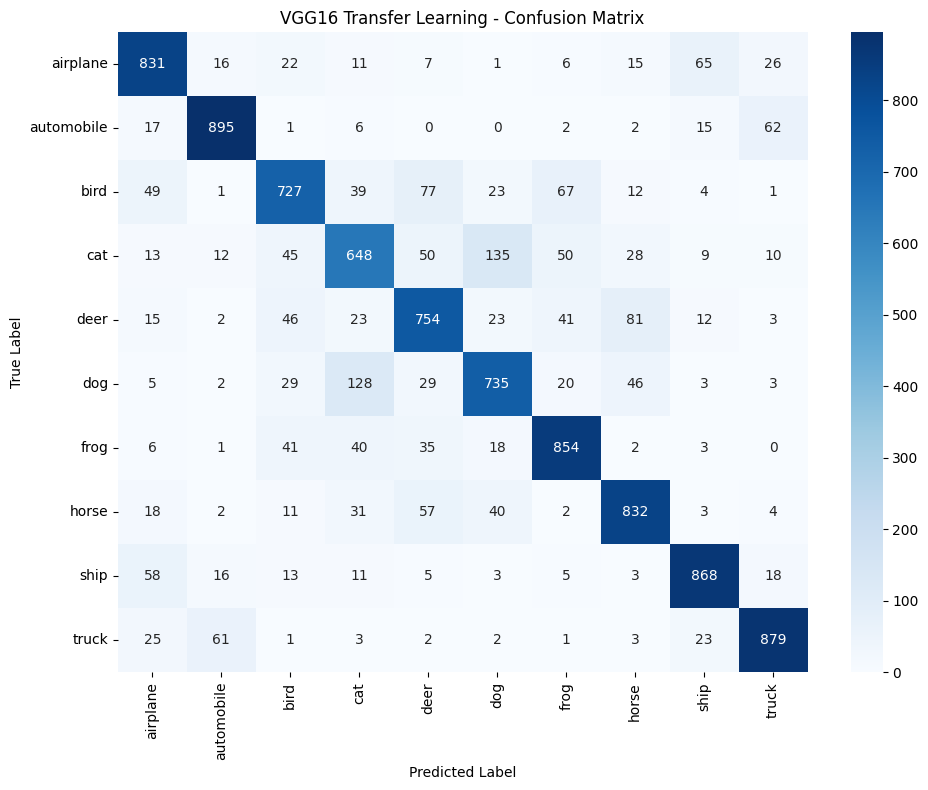

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("VGG16 Transfer Learning - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

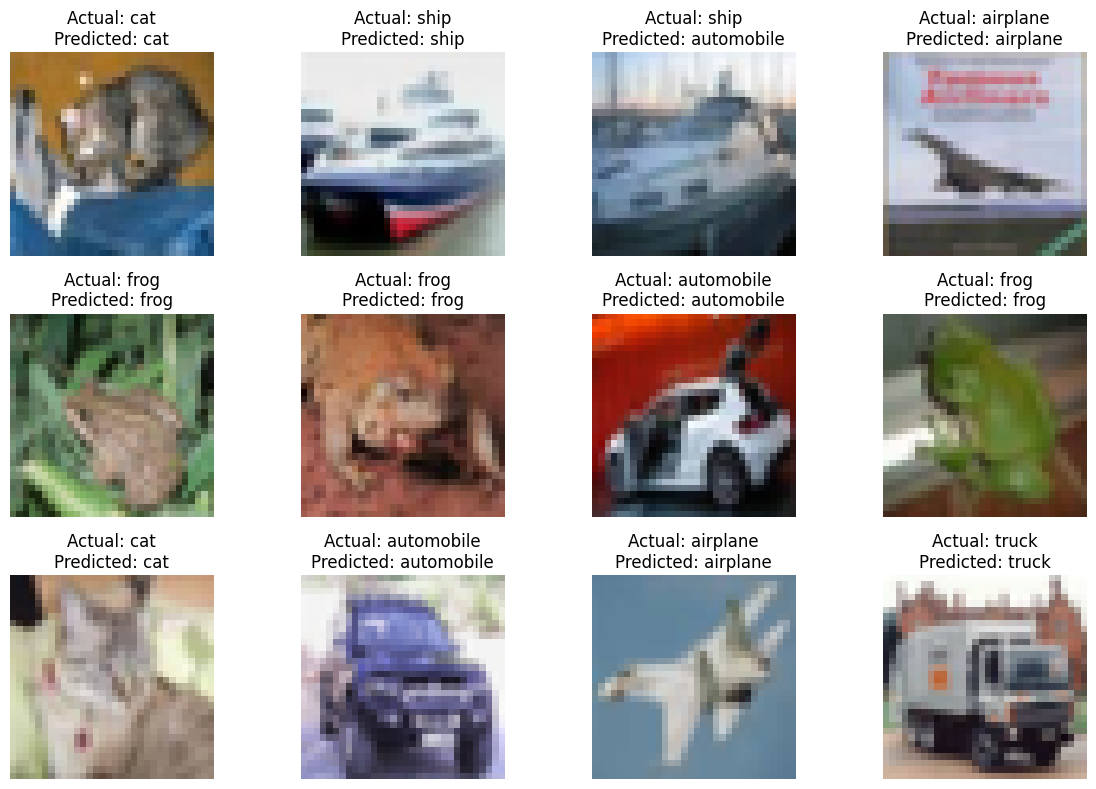

In [24]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    predicted_label = class_names[y_pred[i]]
    actual_label = class_names[y_true[i]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Save the trained VGG16 transfer-learning model

model.save("task4_vgg16_cifar10.keras")

print("Model saved as: task4_vgg16_cifar10.keras")

Model saved as: task4_vgg16_cifar10.keras


In [26]:
# Final Task 4 Transfer Learning result

print("==============================================")
print("TASK 4 - VGG16 TRANSFER LEARNING")
print("==============================================")
print("Dataset       : CIFAR-10")
print("Architecture  : VGG16")
print("Pretrained On : ImageNet")
print(f"Test Loss     : {transfer_test_loss:.4f}")
print(f"Test Accuracy : {transfer_test_accuracy:.4f}")
print("==============================================")

TASK 4 - VGG16 TRANSFER LEARNING
Dataset       : CIFAR-10
Architecture  : VGG16
Pretrained On : ImageNet
Test Loss     : 0.5888
Test Accuracy : 0.8023
